In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("datasets/Salary_Dataset.csv")

In [3]:
df.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


## Testing Linear Relationship between independent and dependent variable

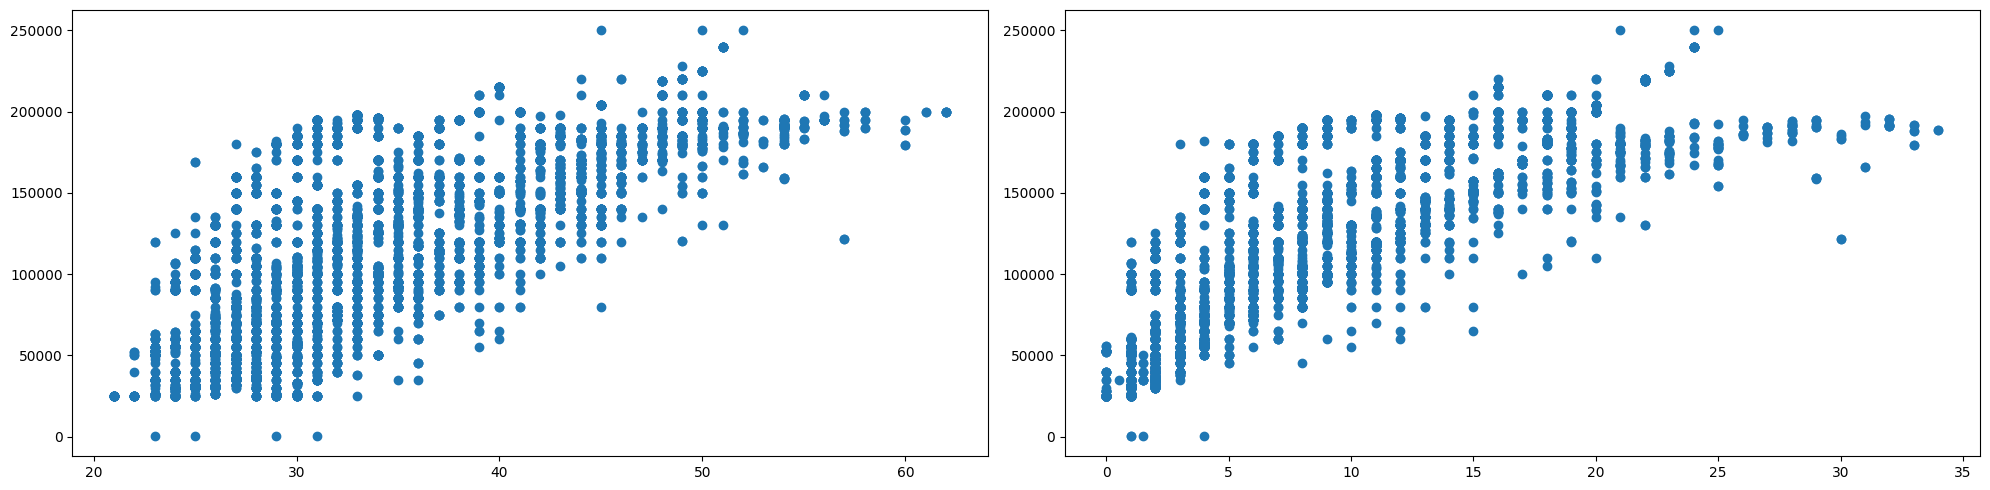

In [4]:
fig, (ax1,ax2) = plt.subplots(ncols=2,nrows=1,figsize=(20,5))
ax1.scatter(df['Age'],df['Salary'])
ax2.scatter(df['Years of Experience'],df['Salary'])
plt.tight_layout()
plt.show()

In [5]:
df.isna().sum()

Age                    2
Years of Experience    3
Salary                 5
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.corr()

,Age,Years of Experience,Salary
Age,1.000000,0.937694,0.728053
Years of Experience,0.937694,1.000000,0.808969
Salary,0.728053,0.808969,1.000000


In [8]:
df[['Years of Experience','Age']].corr()

,Years of Experience,Age
Years of Experience,1.000000,0.937694
Age,0.937694,1.000000


<Axes: >

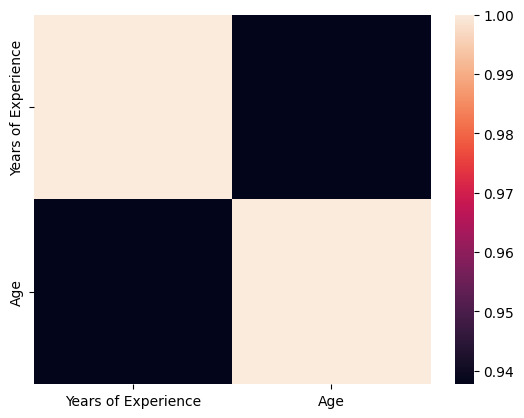

In [9]:
sns.heatmap(df[['Years of Experience','Age']].corr())

In [10]:
!pip install statsmodels


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [12]:
X = df.drop(columns=['Salary'])
y = df['Salary']

In [13]:
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns

In [14]:
vif_data

,feature
0,Age
1,Years of Experience


In [15]:
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X, i) 
                          for i in range((X.shape[1]))] 

In [16]:
vif_data

,feature,VIF
0,Age,5.520692
1,Years of Experience,5.520692


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
X_test

,Age,Years of Experience
2460,25.0,2.0
2230,36.0,8.0
5559,27.0,3.0
3080,24.0,2.0
265,29.0,1.5
...,...,...
4658,38.0,12.0
2155,43.0,14.0
5375,24.0,1.0
4561,28.0,3.0


In [23]:
y_pred

array([ 74827.47948988, 110680.70771332,  80532.01705076, ...,
        67496.93907086,  78906.01419263,  60166.39865184], shape=(1340,))

In [34]:
y_test

2460     90249.0
2230    135000.0
5559     80000.0
3080     64182.0
265      40000.0
          ...   
4658    140000.0
2155    190000.0
5375     55000.0
4561     45000.0
2831     52612.0
Name: Salary, Length: 1340, dtype: float64

In [24]:
residuals = y_test-y_pred

<Axes: xlabel='Salary', ylabel='Count'>

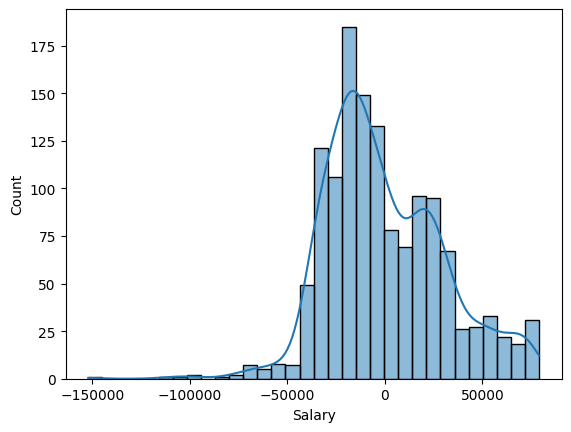

In [25]:
sns.histplot(residuals,kde=True)

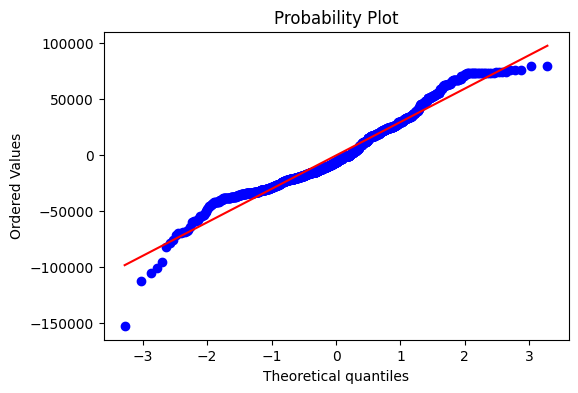

In [26]:
import scipy as sp
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residuals, plot=ax, fit=True)

plt.show()

In [27]:
from scipy import stats

In [28]:
stats.shapiro(residuals)

ShapiroResult(statistic=np.float64(0.9669585607886384), pvalue=np.float64(6.308385295857412e-17))

In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [36]:
r2_score(y_test,y_pred)

0.6779381703942271

Using the Stats Model Linear Regression

In [39]:
import pandas as pd
import statsmodels.api as sm

In [40]:
X

,Age,Years of Experience
0,32.0,5.0
1,28.0,3.0
2,45.0,15.0
3,36.0,7.0
4,52.0,20.0
...,...,...
6699,49.0,20.0
6700,32.0,3.0
6701,30.0,4.0
6702,46.0,14.0


In [41]:
y

0        90000.0
1        65000.0
2       150000.0
3        60000.0
4       200000.0
          ...   
6699    200000.0
6700     50000.0
6701     55000.0
6702    140000.0
6703     35000.0
Name: Salary, Length: 6699, dtype: float64

In [42]:
X = sm.add_constant(X)

In [43]:
X

,const,Age,Years of Experience
0,1.0,32.0,5.0
1,1.0,28.0,3.0
2,1.0,45.0,15.0
3,1.0,36.0,7.0
4,1.0,52.0,20.0
...,...,...,...
6699,1.0,49.0,20.0
6700,1.0,32.0,3.0
6701,1.0,30.0,4.0
6702,1.0,46.0,14.0


In [45]:
model = sm.OLS(y,X)

In [47]:
result = model.fit()

In [48]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     6561.
Date:                Fri, 21 Nov 2025   Prob (F-statistic):               0.00
Time:                        07:17:49   Log-Likelihood:                -78715.
No. Observations:                6699   AIC:                         1.574e+05
Df Residuals:                    6696   BIC:                         1.575e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.005e+05   3

In [50]:
df

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0
...,...,...,...
6699,49.0,20.0,200000.0
6700,32.0,3.0,50000.0
6701,30.0,4.0,55000.0
6702,46.0,14.0,140000.0
